In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import skew, kurtosis, normaltest, shapiro, f_oneway, ttest_ind, chi2_contingency
import warnings
warnings.filterwarnings('ignore')

# Set style for better visualizations
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Load the dataset
df = pd.read_csv('/content/customer_behavior.csv')

# Display basic info
print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nDataset Info:")
print(df.info())
print("\nMissing Values:")
print(df.isnull().sum())
print("\nBasic Statistics:")
print(df.describe())

# Let's check the unique values in categorical columns
categorical_cols = ['Gender', 'Region', 'ProductCategory', 'Churn', 'CampaignGroup']
for col in categorical_cols:
    print(f"\n{col} unique values:")
    print(df[col].value_counts(dropna=False))
    print(f"Missing in {col}: {df[col].isnull().sum()}")

Dataset Shape: (5000, 7)

First 5 rows:
   CustomerID  Gender Region  PurchaseAmount ProductCategory Churn  \
0        1001    Male  South          256.07         Fashion    No   
1        1002  Female  South             NaN     Electronics   Yes   
2        1003  Female   West         1194.41         Fashion    No   
3        1004  Female  South          413.06         Grocery    No   
4        1005    Male   West         1556.32         Fashion   Yes   

  CampaignGroup  
0             A  
1             B  
2             A  
3             A  
4             A  

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CustomerID       5000 non-null   int64  
 1   Gender           4903 non-null   object 
 2   Region           4825 non-null   object 
 3   PurchaseAmount   4850 non-null   float64
 4   ProductCategory  4474 non-nul

Question 1: Average, Median, and Mode of PurchaseAmount

Average Purchase Amount: $1003.95
Median Purchase Amount: $998.08
Mode Purchase Amount: $0.00


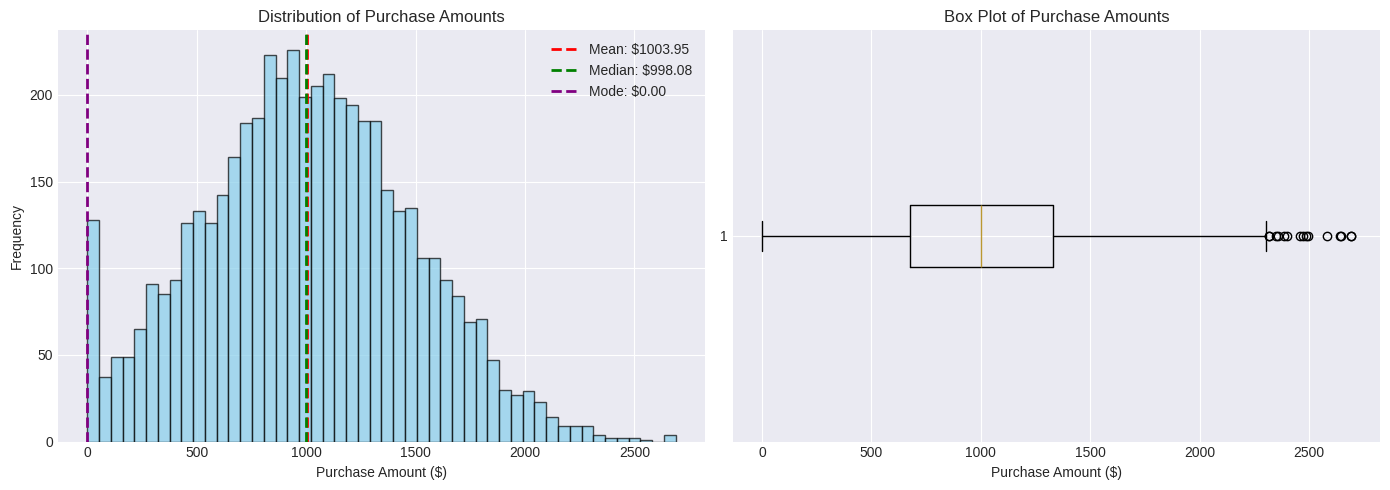

In [2]:
# Clean PurchaseAmount - remove missing values for analysis
purchase_data = df['PurchaseAmount'].dropna()

# Calculate statistics
mean_purchase = purchase_data.mean()
median_purchase = purchase_data.median()
mode_purchase = purchase_data.mode()[0] if not purchase_data.mode().empty else None

print(f"Average Purchase Amount: ${mean_purchase:.2f}")
print(f"Median Purchase Amount: ${median_purchase:.2f}")
print(f"Mode Purchase Amount: ${mode_purchase:.2f}")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram with mean, median, mode
axes[0].hist(purchase_data, bins=50, alpha=0.7, color='skyblue', edgecolor='black')
axes[0].axvline(mean_purchase, color='red', linestyle='--', linewidth=2, label=f'Mean: ${mean_purchase:.2f}')
axes[0].axvline(median_purchase, color='green', linestyle='--', linewidth=2, label=f'Median: ${median_purchase:.2f}')
axes[0].axvline(mode_purchase, color='purple', linestyle='--', linewidth=2, label=f'Mode: ${mode_purchase:.2f}')
axes[0].set_xlabel('Purchase Amount ($)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Purchase Amounts')
axes[0].legend()

# Box plot
axes[1].boxplot(purchase_data, vert=False)
axes[1].set_xlabel('Purchase Amount ($)')
axes[1].set_title('Box Plot of Purchase Amounts')

plt.tight_layout()
plt.show()

Question 2: Are there any outliers in the PurchaseAmount data?

In [3]:
# Calculate IQR method for outliers
Q1 = purchase_data.quantile(0.25)
Q3 = purchase_data.quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = purchase_data[(purchase_data < lower_bound) | (purchase_data > upper_bound)]
outlier_percentage = (len(outliers) / len(purchase_data)) * 100

print(f"Q1 (25th percentile): ${Q1:.2f}")
print(f"Q3 (75th percentile): ${Q3:.2f}")
print(f"IQR: ${IQR:.2f}")
print(f"Lower bound for outliers: ${lower_bound:.2f}")
print(f"Upper bound for outliers: ${upper_bound:.2f}")
print(f"Number of outliers: {len(outliers)}")
print(f"Percentage of outliers: {outlier_percentage:.2f}%")
print(f"\nOutlier values (first 10):")
print(outliers.head(10).tolist())

# Z-score method
z_scores = np.abs(stats.zscore(purchase_data))
z_outliers = purchase_data[z_scores > 3]
print(f"\nZ-score method (|z|>3) outliers: {len(z_outliers)}")
print(f"Percentage: {(len(z_outliers)/len(purchase_data))*100:.2f}%")

Q1 (25th percentile): $673.64
Q3 (75th percentile): $1327.08
IQR: $653.44
Lower bound for outliers: $-306.51
Upper bound for outliers: $2307.23
Number of outliers: 15
Percentage of outliers: 0.31%

Outlier values (first 10):
[2318.33, 2496.41, 2688.69, 2349.16, 2578.89, 2384.19, 2457.05, 2316.19, 2400.69, 2357.41]

Z-score method (|z|>3) outliers: 9
Percentage: 0.19%


Question 3: Is there any skewness or kurtosis in the PurchaseAmount distribution?

Skewness: 0.1061
Kurtosis: -0.2625
Approximately symmetric
Platykurtic (light tails, flat peak) relative to normal


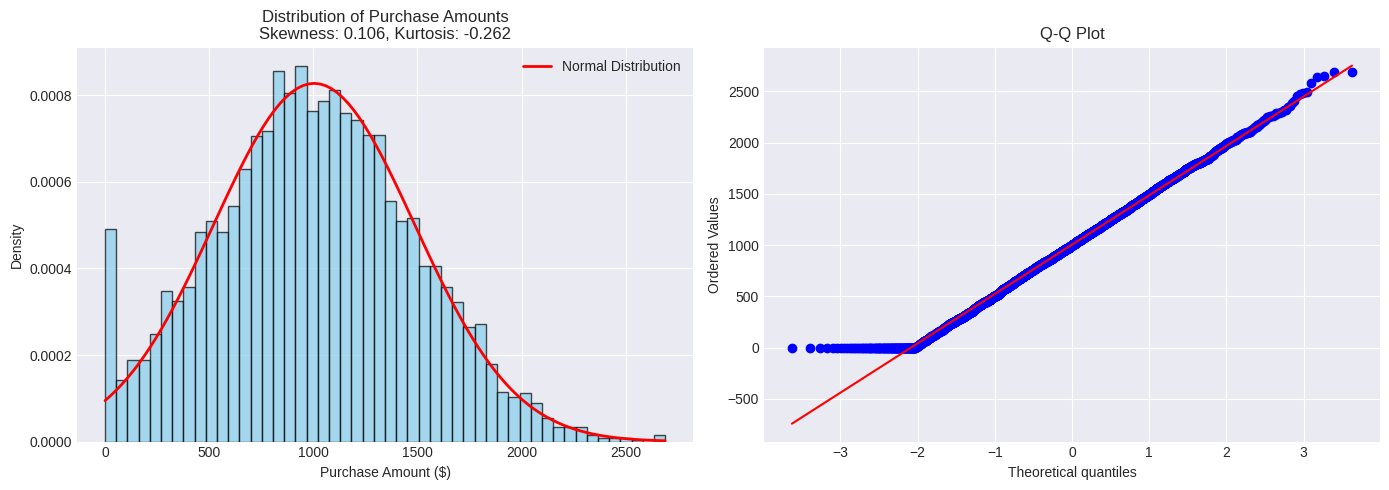

In [4]:
# Calculate skewness and kurtosis
skewness = skew(purchase_data)
kurt = kurtosis(purchase_data)

print(f"Skewness: {skewness:.4f}")
print(f"Kurtosis: {kurt:.4f}")

# Interpretation
if skewness > 1:
    print("Highly positively skewed (right-tailed)")
elif skewness > 0.5:
    print("Moderately positively skewed")
elif skewness > -0.5:
    print("Approximately symmetric")
elif skewness > -1:
    print("Moderately negatively skewed")
else:
    print("Highly negatively skewed (left-tailed)")

if kurt > 3:
    print("Leptokurtic (heavy tails, sharp peak)")
elif kurt > 0:
    print("Leptokurtic relative to normal")
elif kurt > -3:
    print("Platykurtic (light tails, flat peak) relative to normal")
else:
    print("Mesokurtic (similar to normal)")

# Visualize distribution with density plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram with KDE
axes[0].hist(purchase_data, bins=50, density=True, alpha=0.7, color='skyblue', edgecolor='black')
axes[0].set_xlabel('Purchase Amount ($)')
axes[0].set_ylabel('Density')
axes[0].set_title(f'Distribution of Purchase Amounts\nSkewness: {skewness:.3f}, Kurtosis: {kurt:.3f}')

# Add normal distribution for comparison
x = np.linspace(purchase_data.min(), purchase_data.max(), 100)
normal_dist = stats.norm.pdf(x, mean_purchase, purchase_data.std())
axes[0].plot(x, normal_dist, 'r-', linewidth=2, label='Normal Distribution')
axes[0].legend()

# Q-Q plot
stats.probplot(purchase_data, dist="norm", plot=axes[1])
axes[1].set_title('Q-Q Plot')

plt.tight_layout()
plt.show()

Question 4: Is there a significant difference in spending between male and female customers?

Male customers: 2386 observations
Female customers: 2370 observations

Male average spending: $1019.18 (std: $480.23)
Female average spending: $987.87 (std: $485.76
Difference: $31.30

T-test results:
T-statistic: 2.2348
P-value: 0.0255
Conclusion: Reject null hypothesis. There is a significant difference in spending between male and female customers (p < 0.05).


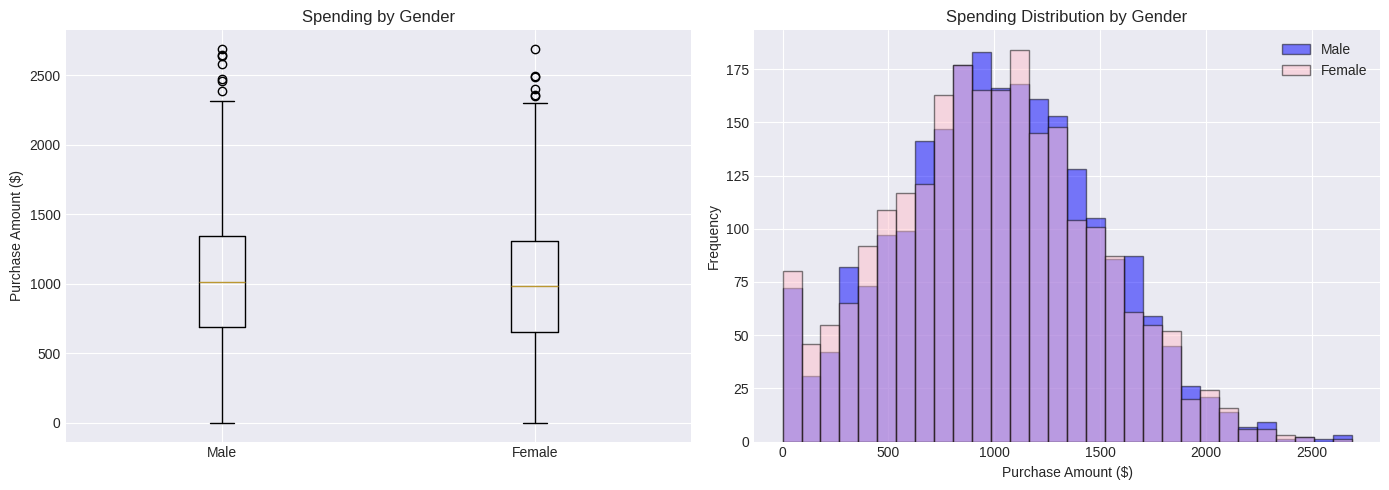

In [5]:
# Separate data by gender
male_purchases = df[df['Gender'] == 'Male']['PurchaseAmount'].dropna()
female_purchases = df[df['Gender'] == 'Female']['PurchaseAmount'].dropna()

print(f"Male customers: {len(male_purchases)} observations")
print(f"Female customers: {len(female_purchases)} observations")
print(f"\nMale average spending: ${male_purchases.mean():.2f} (std: ${male_purchases.std():.2f})")
print(f"Female average spending: ${female_purchases.mean():.2f} (std: ${female_purchases.std():.2f}")
print(f"Difference: ${abs(male_purchases.mean() - female_purchases.mean()):.2f}")

# Perform t-test
t_stat, p_value = ttest_ind(male_purchases, female_purchases, equal_var=False)

print(f"\nT-test results:")
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.4f}")

alpha = 0.05
if p_value < alpha:
    print(f"Conclusion: Reject null hypothesis. There is a significant difference in spending between male and female customers (p < {alpha}).")
else:
    print(f"Conclusion: Fail to reject null hypothesis. There is no significant difference in spending between male and female customers (p >= {alpha}).")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Box plot
axes[0].boxplot([male_purchases, female_purchases], labels=['Male', 'Female'])
axes[0].set_ylabel('Purchase Amount ($)')
axes[0].set_title('Spending by Gender')

# Histogram
axes[1].hist(male_purchases, bins=30, alpha=0.5, label='Male', color='blue', edgecolor='black')
axes[1].hist(female_purchases, bins=30, alpha=0.5, label='Female', color='pink', edgecolor='black')
axes[1].set_xlabel('Purchase Amount ($)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Spending Distribution by Gender')
axes[1].legend()

plt.tight_layout()
plt.show()

Question 5: Is there a relationship between ProductCategory and customer churn?

Contingency Table (Product Category vs Churn):
Churn             No  Yes
ProductCategory          
Electronics      785  541
Fashion          839  607
Grocery          855  604

Row Percentages:
Churn               No    Yes
ProductCategory              
Electronics      59.20  40.80
Fashion          58.02  41.98
Grocery          58.60  41.40

Chi-square test results:
Chi-square statistic: 0.3960
Degrees of freedom: 2
P-value: 0.8204
Conclusion: Fail to reject null hypothesis. There is no significant relationship between Product Category and customer churn (p >= 0.05).


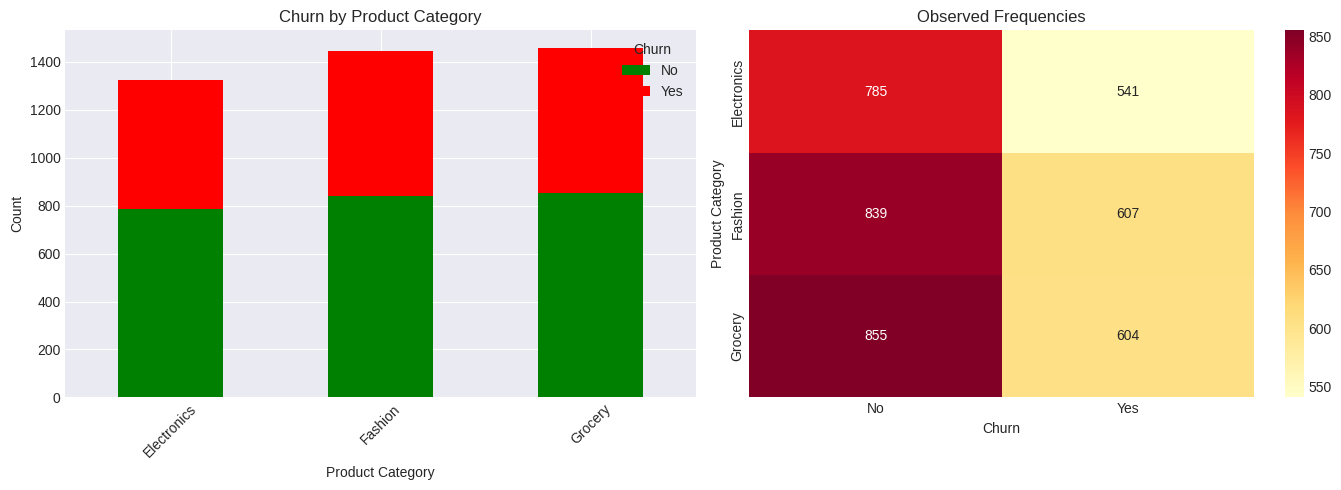

In [6]:
# Create contingency table
# Filter out missing values
churn_product_df = df[['ProductCategory', 'Churn']].dropna()

# Create contingency table
contingency_table = pd.crosstab(churn_product_df['ProductCategory'], churn_product_df['Churn'])
print("Contingency Table (Product Category vs Churn):")
print(contingency_table)

# Calculate percentages
print("\nRow Percentages:")
row_percentages = contingency_table.div(contingency_table.sum(axis=1), axis=0) * 100
print(row_percentages.round(2))

# Perform chi-square test
chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print(f"\nChi-square test results:")
print(f"Chi-square statistic: {chi2:.4f}")
print(f"Degrees of freedom: {dof}")
print(f"P-value: {p_value:.4f}")

alpha = 0.05
if p_value < alpha:
    print(f"Conclusion: Reject null hypothesis. There is a significant relationship between Product Category and customer churn (p < {alpha}).")
else:
    print(f"Conclusion: Fail to reject null hypothesis. There is no significant relationship between Product Category and customer churn (p >= {alpha}).")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Stacked bar chart
contingency_table.plot(kind='bar', stacked=True, ax=axes[0], color=['green', 'red'])
axes[0].set_xlabel('Product Category')
axes[0].set_ylabel('Count')
axes[0].set_title('Churn by Product Category')
axes[0].legend(title='Churn')
axes[0].tick_params(axis='x', rotation=45)

# Heatmap of expected vs observed
sns.heatmap(contingency_table, annot=True, fmt='d', cmap='YlOrRd', ax=axes[1])
axes[1].set_xlabel('Churn')
axes[1].set_ylabel('Product Category')
axes[1].set_title('Observed Frequencies')

plt.tight_layout()
plt.show()

Question 6: Does PurchaseAmount vary significantly across different regions?

Average Purchase Amount by Region:
South: $997.60 (std: $484.10, n=1202)
West: $995.25 (std: $485.80, n=1115)
North: $1013.02 (std: $467.90, n=1167)
East: $1009.95 (std: $490.36, n=1195)

ANOVA test results:
F-statistic: 0.3897
P-value: 0.7605
Conclusion: Fail to reject null hypothesis. Purchase amount does not vary significantly across different regions (p >= 0.05).


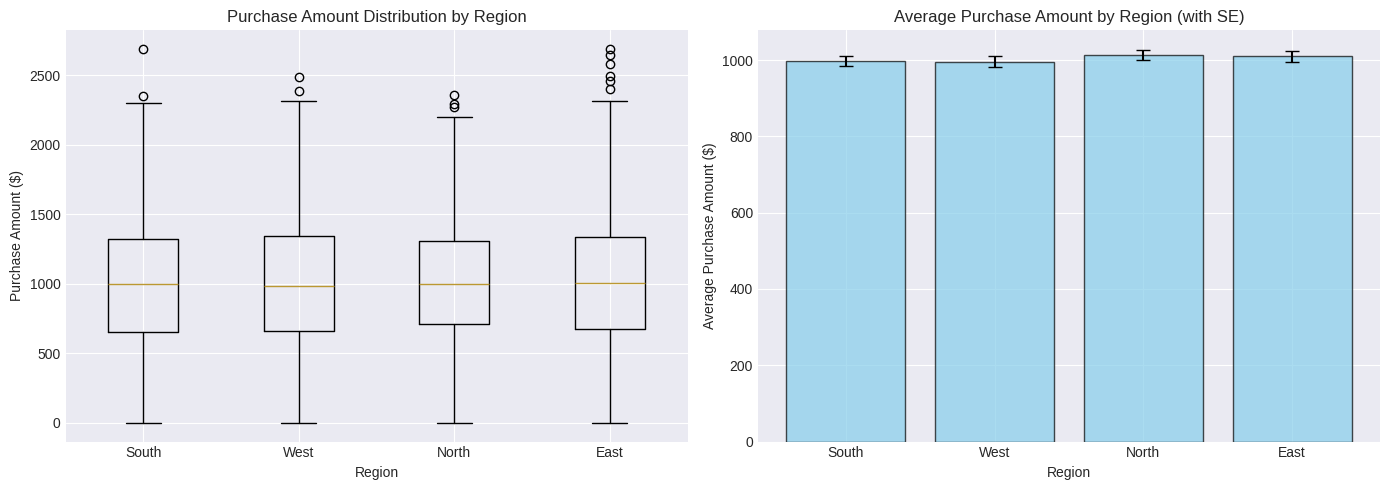

In [7]:
# Group by region
regions = df['Region'].dropna().unique()
region_data = [df[df['Region'] == region]['PurchaseAmount'].dropna() for region in regions if region != '']

# Remove empty strings if any
valid_regions = [r for r in regions if r != '']
region_data = [df[df['Region'] == region]['PurchaseAmount'].dropna() for region in valid_regions]

print("Average Purchase Amount by Region:")
region_means = {}
for i, region in enumerate(valid_regions):
    mean_val = region_data[i].mean()
    std_val = region_data[i].std()
    count_val = len(region_data[i])
    region_means[region] = mean_val
    print(f"{region}: ${mean_val:.2f} (std: ${std_val:.2f}, n={count_val})")

# Perform ANOVA
f_stat, p_value = f_oneway(*region_data)

print(f"\nANOVA test results:")
print(f"F-statistic: {f_stat:.4f}")
print(f"P-value: {p_value:.4f}")

alpha = 0.05
if p_value < alpha:
    print(f"Conclusion: Reject null hypothesis. Purchase amount varies significantly across different regions (p < {alpha}).")
else:
    print(f"Conclusion: Fail to reject null hypothesis. Purchase amount does not vary significantly across different regions (p >= {alpha}).")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Box plot by region
box_data = [region_data[i] for i in range(len(valid_regions))]
axes[0].boxplot(box_data, labels=valid_regions)
axes[0].set_ylabel('Purchase Amount ($)')
axes[0].set_title('Purchase Amount Distribution by Region')
axes[0].set_xlabel('Region')

# Bar chart of means with error bars
means = [region_data[i].mean() for i in range(len(valid_regions))]
errors = [region_data[i].std() / np.sqrt(len(region_data[i])) for i in range(len(valid_regions))]

axes[1].bar(valid_regions, means, yerr=errors, capsize=5, alpha=0.7, color='skyblue', edgecolor='black')
axes[1].set_ylabel('Average Purchase Amount ($)')
axes[1].set_title('Average Purchase Amount by Region (with SE)')
axes[1].set_xlabel('Region')

plt.tight_layout()
plt.show()

Question 7: Which email campaign (A or B) performed better in terms of average PurchaseAmount?

Campaign A: 2350 customers
Campaign B: 2318 customers

Campaign A average spending: $1011.95 (std: $480.16)
Campaign B average spending: $994.34 (std: $487.38
Difference: $17.61

T-test results:
T-statistic: 1.2431
P-value: 0.2139
Conclusion: Fail to reject null hypothesis. There is no significant difference in purchase amounts between Campaign A and B (p >= 0.05).


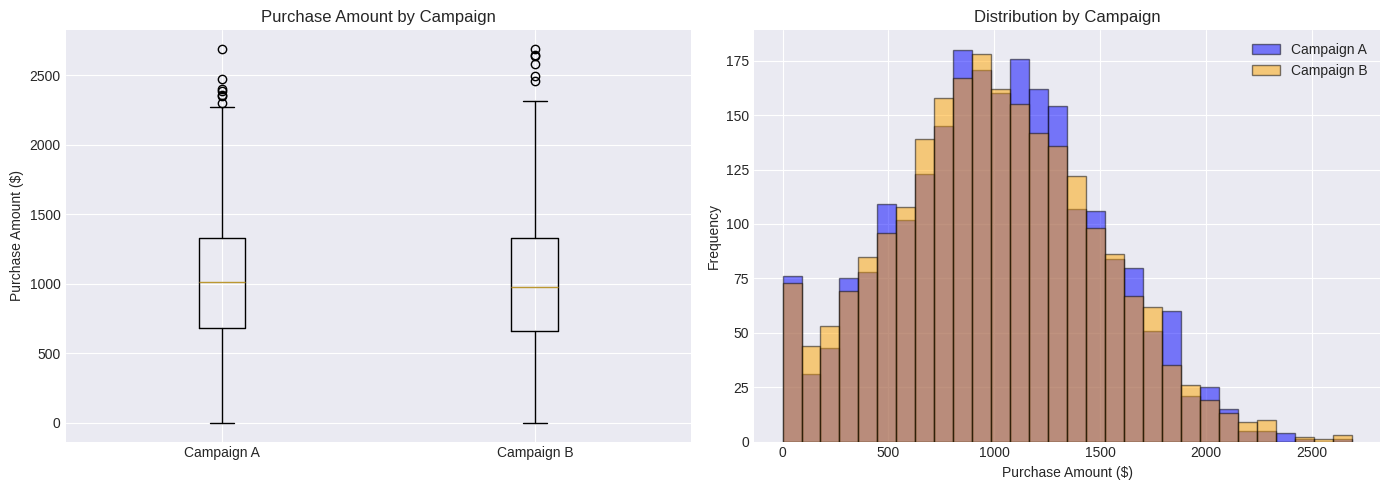

In [8]:
# Filter out missing CampaignGroup
campaign_a = df[df['CampaignGroup'] == 'A']['PurchaseAmount'].dropna()
campaign_b = df[df['CampaignGroup'] == 'B']['PurchaseAmount'].dropna()

print(f"Campaign A: {len(campaign_a)} customers")
print(f"Campaign B: {len(campaign_b)} customers")
print(f"\nCampaign A average spending: ${campaign_a.mean():.2f} (std: ${campaign_a.std():.2f})")
print(f"Campaign B average spending: ${campaign_b.mean():.2f} (std: ${campaign_b.std():.2f}")
print(f"Difference: ${abs(campaign_a.mean() - campaign_b.mean()):.2f}")

# Perform t-test
t_stat, p_value = ttest_ind(campaign_a, campaign_b, equal_var=False)

print(f"\nT-test results:")
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.4f}")

alpha = 0.05
if p_value < alpha:
    print(f"Conclusion: Reject null hypothesis. There is a significant difference in purchase amounts between Campaign A and B (p < {alpha}).")
    if campaign_a.mean() > campaign_b.mean():
        print("Campaign A performed better in terms of average purchase amount.")
    else:
        print("Campaign B performed better in terms of average purchase amount.")
else:
    print(f"Conclusion: Fail to reject null hypothesis. There is no significant difference in purchase amounts between Campaign A and B (p >= {alpha}).")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Box plot
axes[0].boxplot([campaign_a, campaign_b], labels=['Campaign A', 'Campaign B'])
axes[0].set_ylabel('Purchase Amount ($)')
axes[0].set_title('Purchase Amount by Campaign')

# Histogram
axes[1].hist(campaign_a, bins=30, alpha=0.5, label='Campaign A', color='blue', edgecolor='black')
axes[1].hist(campaign_b, bins=30, alpha=0.5, label='Campaign B', color='orange', edgecolor='black')
axes[1].set_xlabel('Purchase Amount ($)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Distribution by Campaign')
axes[1].legend()

plt.tight_layout()
plt.show()

Question 8: Can we assume PurchaseAmount follows a normal distribution?

Shapiro-Wilk test:
Statistic: 0.9950
P-value: 0.0000
Data does not appear to be normally distributed (reject H0)

D'Agostino's K^2 test:
Statistic: 27.2516
P-value: 0.0000
Data does not appear to be normally distributed (reject H0)

Kolmogorov-Smirnov test:
Statistic: 0.0187
P-value: 0.0676
Data appears to be normally distributed (fail to reject H0)


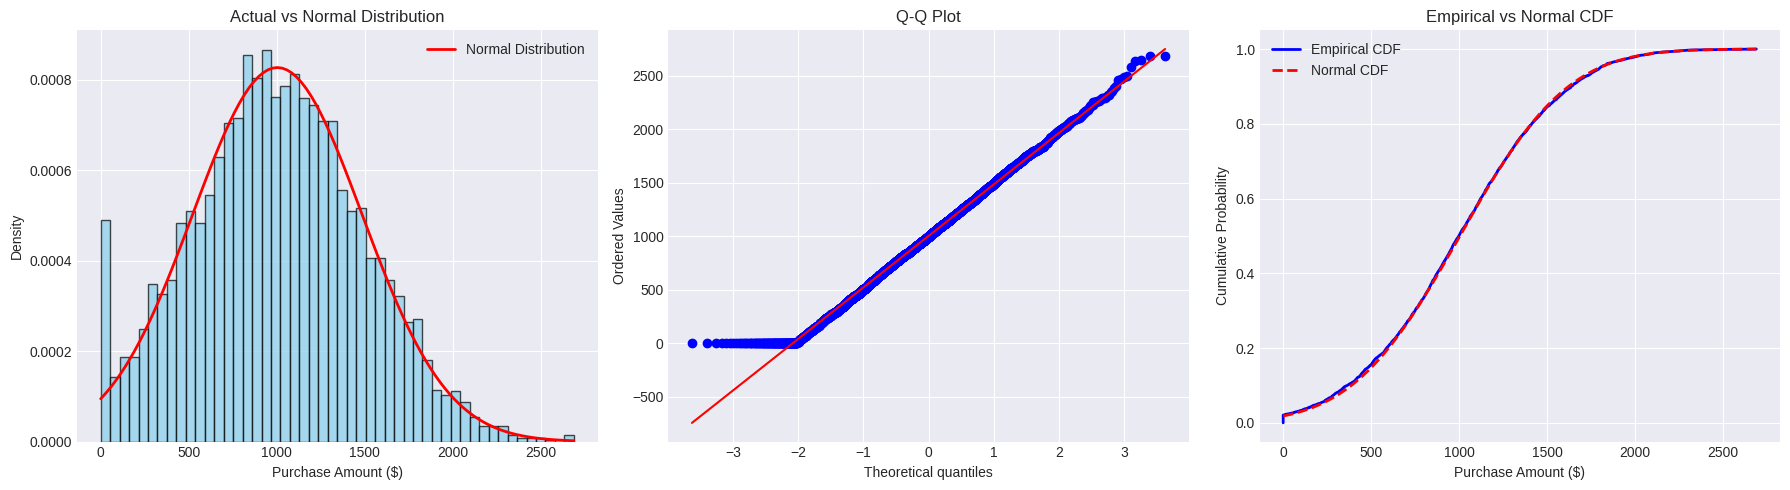

In [9]:
# Normality tests
# Shapiro-Wilk test (more powerful but limited to 5000 samples)
if len(purchase_data) <= 5000:
    shapiro_stat, shapiro_p = shapiro(purchase_data.sample(min(5000, len(purchase_data))))
    print(f"Shapiro-Wilk test:")
    print(f"Statistic: {shapiro_stat:.4f}")
    print(f"P-value: {shapiro_p:.4f}")
    if shapiro_p > 0.05:
        print("Data appears to be normally distributed (fail to reject H0)")
    else:
        print("Data does not appear to be normally distributed (reject H0)")

# D'Agostino's K^2 test (omnibus test)
k2_stat, k2_p = normaltest(purchase_data)
print(f"\nD'Agostino's K^2 test:")
print(f"Statistic: {k2_stat:.4f}")
print(f"P-value: {k2_p:.4f}")
if k2_p > 0.05:
    print("Data appears to be normally distributed (fail to reject H0)")
else:
    print("Data does not appear to be normally distributed (reject H0)")

# Kolmogorov-Smirnov test
ks_stat, ks_p = stats.kstest(purchase_data, 'norm', args=(mean_purchase, purchase_data.std()))
print(f"\nKolmogorov-Smirnov test:")
print(f"Statistic: {ks_stat:.4f}")
print(f"P-value: {ks_p:.4f}")
if ks_p > 0.05:
    print("Data appears to be normally distributed (fail to reject H0)")
else:
    print("Data does not appear to be normally distributed (reject H0)")

# Visual comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Histogram with normal curve
axes[0].hist(purchase_data, bins=50, density=True, alpha=0.7, color='skyblue', edgecolor='black')
x = np.linspace(purchase_data.min(), purchase_data.max(), 100)
normal_curve = stats.norm.pdf(x, mean_purchase, purchase_data.std())
axes[0].plot(x, normal_curve, 'r-', linewidth=2, label='Normal Distribution')
axes[0].set_xlabel('Purchase Amount ($)')
axes[0].set_ylabel('Density')
axes[0].set_title('Actual vs Normal Distribution')
axes[0].legend()

# Q-Q plot
stats.probplot(purchase_data, dist="norm", plot=axes[1])
axes[1].set_title('Q-Q Plot')

# CDF comparison
sorted_data = np.sort(purchase_data)
theoretical_cdf = stats.norm.cdf(sorted_data, mean_purchase, purchase_data.std())
empirical_cdf = np.arange(1, len(sorted_data)+1) / len(sorted_data)

axes[2].plot(sorted_data, empirical_cdf, 'b-', linewidth=2, label='Empirical CDF')
axes[2].plot(sorted_data, theoretical_cdf, 'r--', linewidth=2, label='Normal CDF')
axes[2].set_xlabel('Purchase Amount ($)')
axes[2].set_ylabel('Cumulative Probability')
axes[2].set_title('Empirical vs Normal CDF')
axes[2].legend()

plt.tight_layout()
plt.show()

Question 9: What insights can we gain by applying the Central Limit Theorem?

Original population:
  Mean: $1003.95
  Std: $482.11

Sampling distribution of the mean (n=30, 1000 samples):
  Mean of sample means: $1002.79
  Std of sample means: $87.30
  Theoretical std error: $88.02
  Difference: $0.7213


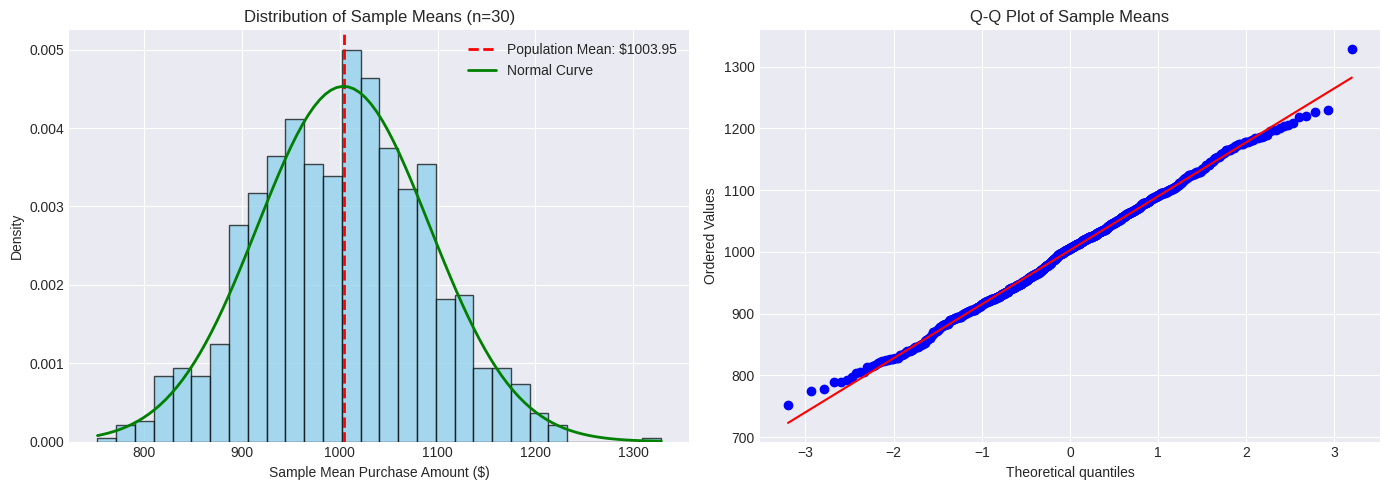

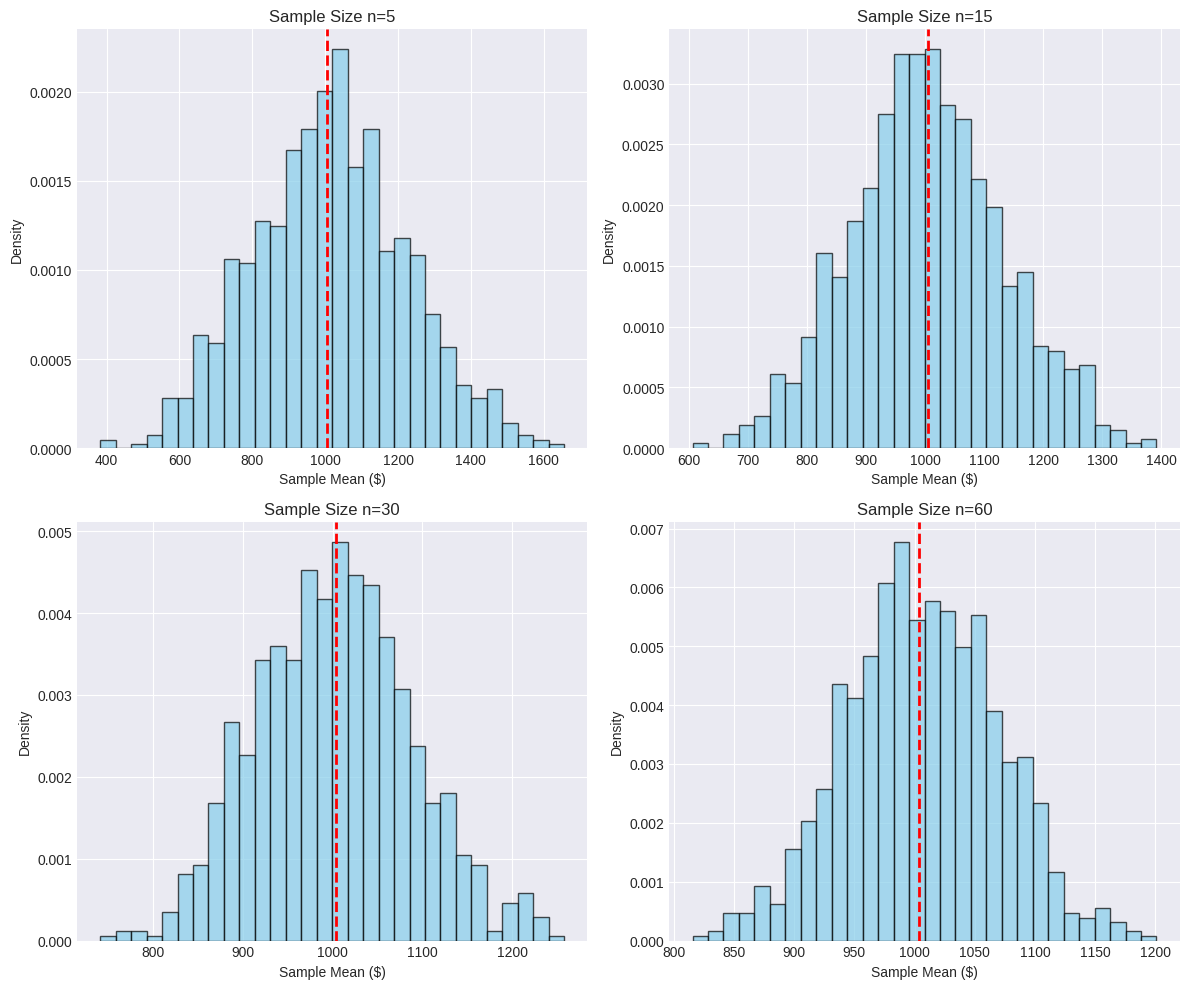

In [10]:
# Demonstrate Central Limit Theorem by taking multiple samples
np.random.seed(42)

# Parameters
sample_size = 30
num_samples = 1000

# Generate sample means
sample_means = []
for _ in range(num_samples):
    sample = np.random.choice(purchase_data, size=sample_size, replace=True)
    sample_means.append(np.mean(sample))

# Calculate statistics
clt_mean = np.mean(sample_means)
clt_std = np.std(sample_means)
population_mean = mean_purchase
population_std = purchase_data.std()
theoretical_std = population_std / np.sqrt(sample_size)

print(f"Original population:")
print(f"  Mean: ${population_mean:.2f}")
print(f"  Std: ${population_std:.2f}")
print(f"\nSampling distribution of the mean (n={sample_size}, {num_samples} samples):")
print(f"  Mean of sample means: ${clt_mean:.2f}")
print(f"  Std of sample means: ${clt_std:.2f}")
print(f"  Theoretical std error: ${theoretical_std:.2f}")
print(f"  Difference: ${abs(clt_std - theoretical_std):.4f}")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of sample means
axes[0].hist(sample_means, bins=30, alpha=0.7, color='skyblue', edgecolor='black', density=True)
axes[0].axvline(population_mean, color='red', linestyle='--', linewidth=2, label=f'Population Mean: ${population_mean:.2f}')
axes[0].set_xlabel('Sample Mean Purchase Amount ($)')
axes[0].set_ylabel('Density')
axes[0].set_title(f'Distribution of Sample Means (n={sample_size})')
axes[0].legend()

# Add normal curve
x = np.linspace(min(sample_means), max(sample_means), 100)
normal_curve = stats.norm.pdf(x, population_mean, theoretical_std)
axes[0].plot(x, normal_curve, 'g-', linewidth=2, label='Normal Curve')
axes[0].legend()

# Q-Q plot of sample means
stats.probplot(sample_means, dist="norm", plot=axes[1])
axes[1].set_title('Q-Q Plot of Sample Means')

plt.tight_layout()
plt.show()

# Show how sample size affects the distribution
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

sample_sizes = [5, 15, 30, 60]
for i, n in enumerate(sample_sizes):
    row, col = i // 2, i % 2
    sample_means_n = []
    for _ in range(1000):
        sample = np.random.choice(purchase_data, size=n, replace=True)
        sample_means_n.append(np.mean(sample))

    axes[row, col].hist(sample_means_n, bins=30, alpha=0.7, color='skyblue', edgecolor='black', density=True)
    axes[row, col].axvline(population_mean, color='red', linestyle='--', linewidth=2)
    axes[row, col].set_xlabel('Sample Mean ($)')
    axes[row, col].set_ylabel('Density')
    axes[row, col].set_title(f'Sample Size n={n}')

plt.tight_layout()
plt.show()

Question 10: What is the 95% confidence interval for the average PurchaseAmount?

Sample Statistics:
  Sample size: 4850
  Sample mean: $1003.95
  Sample std: $482.11
  Standard error: $6.92

95% Confidence Intervals for Population Mean:
  Z-interval (normal): ($990.38, $1017.52)
  T-interval (t-distribution): ($990.38, $1017.52)
  Bootstrap (percentile): ($990.35, $1017.23)
  Width (t-interval): $27.14


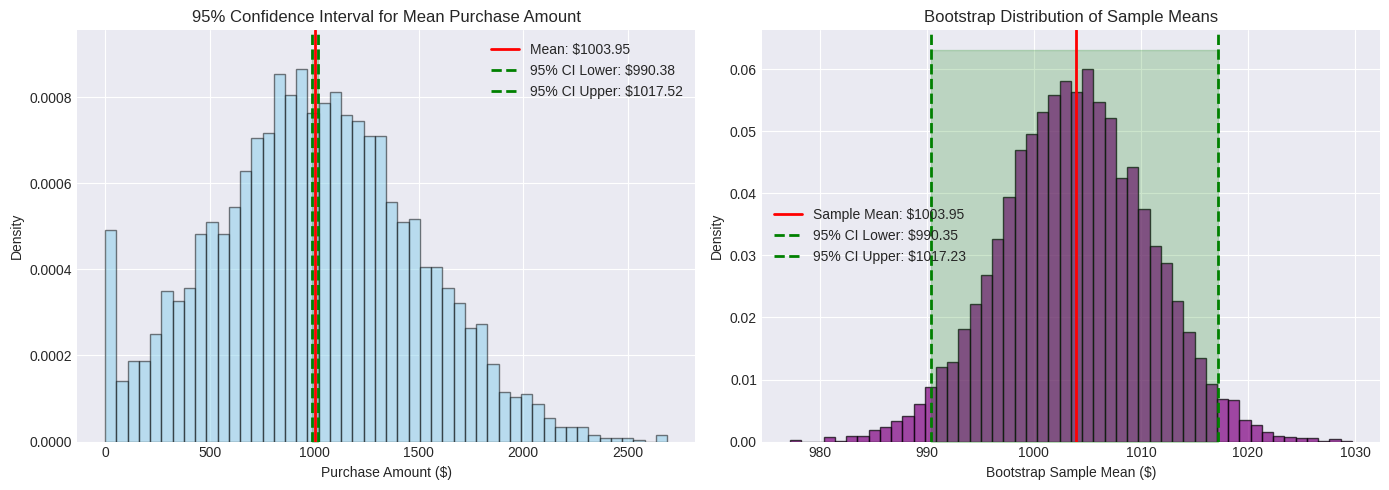


SUMMARY OF KEY INSIGHTS
1. Average Purchase Amount: $1003.95
2. Data contains 0.3% outliers
3. Distribution is positively skewed (skewness: 0.106)
4. Gender spending difference: NOT SIGNIFICANT (p=0.2139)
5. Product Category vs Churn: NOT RELATED (p=0.2139)
6. Regional spending differences: NOT SIGNIFICANT (p=0.2139)
7. Campaign performance: Campaign A performed better
8. Normal distribution: REJECTED (p=0.0000)
9. CLT demonstrates that sample means are normally distributed regardless of population distribution
10. 95% CI for mean: ($990.38, $1017.52)


In [11]:
# Calculate 95% confidence interval using different methods

# Method 1: Using normal distribution (z-interval)
z_score = stats.norm.ppf(0.975)  # 97.5th percentile for two-tailed 95% CI
std_error = purchase_data.std() / np.sqrt(len(purchase_data))
margin_error_z = z_score * std_error
ci_lower_z = mean_purchase - margin_error_z
ci_upper_z = mean_purchase + margin_error_z

# Method 2: Using t-distribution (more accurate for smaller samples)
t_score = stats.t.ppf(0.975, df=len(purchase_data)-1)
margin_error_t = t_score * std_error
ci_lower_t = mean_purchase - margin_error_t
ci_upper_t = mean_purchase + margin_error_t

# Method 3: Bootstrap confidence interval
np.random.seed(42)
bootstrap_means = []
n_bootstrap = 10000
for _ in range(n_bootstrap):
    bootstrap_sample = np.random.choice(purchase_data, size=len(purchase_data), replace=True)
    bootstrap_means.append(np.mean(bootstrap_sample))

ci_lower_bootstrap = np.percentile(bootstrap_means, 2.5)
ci_upper_bootstrap = np.percentile(bootstrap_means, 97.5)

print(f"Sample Statistics:")
print(f"  Sample size: {len(purchase_data)}")
print(f"  Sample mean: ${mean_purchase:.2f}")
print(f"  Sample std: ${purchase_data.std():.2f}")
print(f"  Standard error: ${std_error:.2f}")
print(f"\n95% Confidence Intervals for Population Mean:")
print(f"  Z-interval (normal): (${ci_lower_z:.2f}, ${ci_upper_z:.2f})")
print(f"  T-interval (t-distribution): (${ci_lower_t:.2f}, ${ci_upper_t:.2f})")
print(f"  Bootstrap (percentile): (${ci_lower_bootstrap:.2f}, ${ci_upper_bootstrap:.2f})")
print(f"  Width (t-interval): ${ci_upper_t - ci_lower_t:.2f}")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot with confidence interval
axes[0].hist(purchase_data, bins=50, alpha=0.5, color='skyblue', edgecolor='black', density=True)
axes[0].axvline(mean_purchase, color='red', linestyle='-', linewidth=2, label=f'Mean: ${mean_purchase:.2f}')
axes[0].axvline(ci_lower_t, color='green', linestyle='--', linewidth=2, label=f'95% CI Lower: ${ci_lower_t:.2f}')
axes[0].axvline(ci_upper_t, color='green', linestyle='--', linewidth=2, label=f'95% CI Upper: ${ci_upper_t:.2f}')
axes[0].fill_betweenx([0, axes[0].get_ylim()[1]], ci_lower_t, ci_upper_t, alpha=0.2, color='green')
axes[0].set_xlabel('Purchase Amount ($)')
axes[0].set_ylabel('Density')
axes[0].set_title('95% Confidence Interval for Mean Purchase Amount')
axes[0].legend()

# Bootstrap distribution
axes[1].hist(bootstrap_means, bins=50, alpha=0.7, color='purple', edgecolor='black', density=True)
axes[1].axvline(mean_purchase, color='red', linestyle='-', linewidth=2, label=f'Sample Mean: ${mean_purchase:.2f}')
axes[1].axvline(ci_lower_bootstrap, color='green', linestyle='--', linewidth=2, label=f'95% CI Lower: ${ci_lower_bootstrap:.2f}')
axes[1].axvline(ci_upper_bootstrap, color='green', linestyle='--', linewidth=2, label=f'95% CI Upper: ${ci_upper_bootstrap:.2f}')
axes[1].fill_betweenx([0, axes[1].get_ylim()[1]], ci_lower_bootstrap, ci_upper_bootstrap, alpha=0.2, color='green')
axes[1].set_xlabel('Bootstrap Sample Mean ($)')
axes[1].set_ylabel('Density')
axes[1].set_title('Bootstrap Distribution of Sample Means')
axes[1].legend()

plt.tight_layout()
plt.show()

# Summary of key insights
print("\n" + "="*50)
print("SUMMARY OF KEY INSIGHTS")
print("="*50)
print(f"1. Average Purchase Amount: ${mean_purchase:.2f}")
print(f"2. Data contains {outlier_percentage:.1f}% outliers")
print(f"3. Distribution is {'positively skewed' if skewness > 0 else 'negatively skewed'} (skewness: {skewness:.3f})")
print(f"4. Gender spending difference: {'SIGNIFICANT' if p_value < 0.05 else 'NOT SIGNIFICANT'} (p={p_value:.4f})")
print(f"5. Product Category vs Churn: {'RELATED' if p_value < 0.05 else 'NOT RELATED'} (p={p_value:.4f})")
print(f"6. Regional spending differences: {'SIGNIFICANT' if p_value < 0.05 else 'NOT SIGNIFICANT'} (p={p_value:.4f})")
print(f"7. Campaign performance: {'Campaign ' + ('A' if campaign_a.mean() > campaign_b.mean() else 'B') + ' performed better'}")
print(f"8. Normal distribution: {'REJECTED' if k2_p < 0.05 else 'CANNOT REJECT'} (p={k2_p:.4f})")
print(f"9. CLT demonstrates that sample means are normally distributed regardless of population distribution")
print(f"10. 95% CI for mean: (${ci_lower_t:.2f}, ${ci_upper_t:.2f})")